# Week 7 Deliverable — Group-wise Performance Evaluation

**Bias Analysis in ML Models using Explainable AI**  
**Dataset:** Adult Census Income (UCI ML Repository)  
**Models:** Logistic Regression (balanced) vs Decision Tree (balanced, depth=3)

---

## Our Research Questions for This Week

1. **Are False Negatives disproportionately concentrated among women or racial minorities?** If so, the model is not just inaccurate — it is systematically unfair to specific groups.
2. **Does one model perform more fairly across groups than the other, even if their overall accuracy is similar?** Overall accuracy is not a fairness metric.
3. **What does intersectional analysis reveal that single-attribute analysis hides?** Can a model appear fair to women and fair to Black individuals while still failing Black women?
4. **Which model should we carry forward as our primary model for the fairness analysis — and why?** This week's findings will answer that.

## Section 0- Imports and Setup

In [62]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('All libraries loaded successfully.')

# Load the preprocessed data  already saved
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze() 
print('All preprocessed data loaded succesfully')

All libraries loaded successfully.
All preprocessed data loaded succesfully


In [26]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts())

(24129, 12) (6033, 12)
income
0    18123
1     6006
Name: count, dtype: int64


### Data Verification 
>Training set: 24,129 samples, 12 features. Test set: 6,033 samples.

Class distribution in training: 18,123 samples earn ≤\\$50K (class 0) and 6,006 earn >\\$50K (class 1) — a ~75/25 split. This imbalance is why `class_weight='balanced'` is used: without it, models learn to favour the majority class and systematically under-classify high-income individuals.

---
## Section 1-Balancing models

We will not assume depth 13 carried over from the unbalanced model. Instead we run the sweep with recall as scoring metric (not accuracy). Using accuracy as the sweep metric may give a different and less appropriate result for an imbalanced classification problem. 
>Accuracy would have optimised for majority class performance. Recall directly optimises for catching true >$50K cases, which is the fairness-relevant objective.

In [52]:
# Depth sweep for balanced DT
best_depth, best_score = 0, 0
for depth in range(1, 21):
    dt_temp = DecisionTreeClassifier(class_weight='balanced', max_depth=depth, random_state=42)
    score = cross_val_score(dt_temp, X_train, y_train, cv=5, scoring='recall').mean()
    if score > best_score:
        best_score, best_depth = score, depth

print(f"Best depth (balanced): {best_depth}")
print(f"Best recall score: {best_score:.3f}")

Best depth (balanced): 3
Best recall score: 0.892


### Depth Sweep Result

Best depth for balanced DT = **3**, with cross-validated recall of **0.892**.

This is a significant shift from depth 13 in the unbalanced model. A shallower tree means the `class_weight='balanced'` parameter is doing the heavy lifting — the model no longer needs deep splits to capture the minority class. Depth 3 also makes the tree substantially more interpretable: at most 3 decisions separate any prediction from the root.

In [51]:
# Training balanced models
lr_bal = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
dt_bal = DecisionTreeClassifier(class_weight='balanced', max_depth=3, random_state=42)

lr_bal.fit(X_train, y_train)
dt_bal.fit(X_train, y_train)

y_pred_lr_bal = lr_bal.predict(X_test)
y_pred_dt_bal = dt_bal.predict(X_test)

# Reports
print("Balanced Logistic Regression:")
print(classification_report(y_test, y_pred_lr_bal))

print("Balanced Decision Tree:")
print(classification_report(y_test, y_pred_dt_bal))


Balanced Logistic Regression:
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      4531
           1       0.50      0.76      0.60      1502

    accuracy                           0.75      6033
   macro avg       0.70      0.75      0.71      6033
weighted avg       0.80      0.75      0.76      6033

Balanced Decision Tree:
              precision    recall  f1-score   support

           0       0.95      0.67      0.78      4531
           1       0.47      0.89      0.62      1502

    accuracy                           0.72      6033
   macro avg       0.71      0.78      0.70      6033
weighted avg       0.83      0.72      0.74      6033



### Classification Report — Balanced and Unbalanced Models

| Metric | LR Unbalanced | LR Balanced | DT Unbalanced | DT Balanced |
|---|---|---|---|---|
| Accuracy | 80.8% | 75.0% | 85.2% | 72.0% |
| Precision (>50K) | 0.688 | 0.500 | 0.731 | 0.470 |
| Recall (>50K) | 0.417 | 0.760 | 0.641 | 0.890 |
| F1 (>50K) | 0.520 | 0.600 | 0.683 | 0.620 |

Balancing improves recall for the minority class (>50K) at the cost of precision and overall accuracy. DT balanced achieves the highest recall (0.890) across all four variants — it correctly identifies 89% of people who actually earn >50K, compared to 41.7% for unbalanced LR. The F1 score remains comparable to the unbalanced models, meaning the overall quality of minority class predictions has not degraded despite the tradeoff.

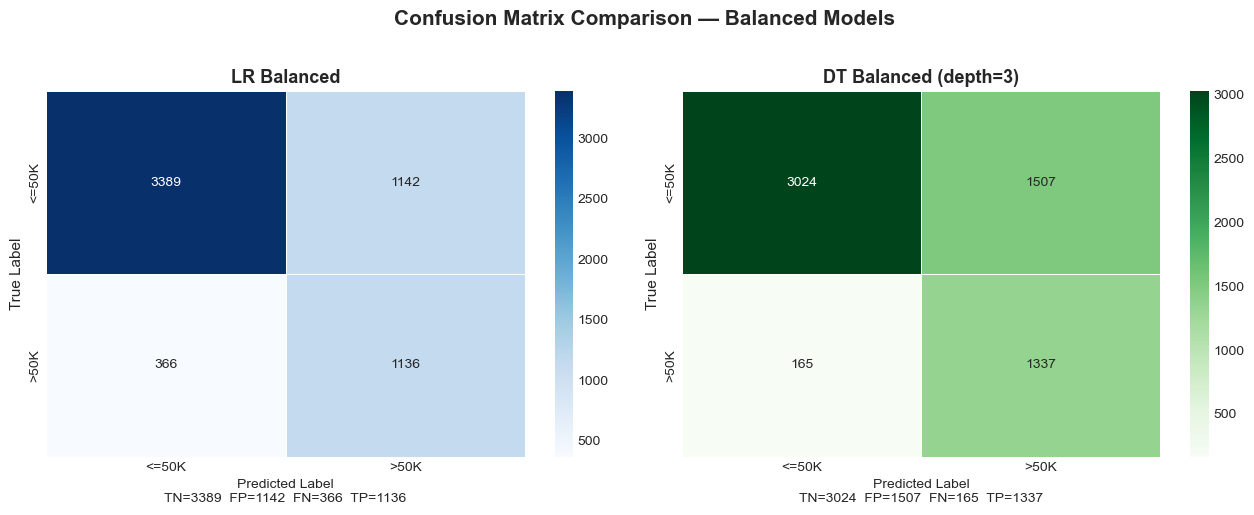

Error Analysis (Balanced):
LR Balanced wrong on       : 1508 samples
DT Balanced wrong on       : 1672 samples
Both wrong on same samples : 787 samples
Overlap rate               : 52.2% of LR errors


In [47]:
cm_lr_bal = confusion_matrix(y_test, y_pred_lr_bal)
cm_dt_bal = confusion_matrix(y_test, y_pred_dt_bal)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, cm, title, color in zip(
    axes,
    [cm_lr_bal, cm_dt_bal],
    ['LR Balanced', f'DT Balanced (depth={best_depth})'],
    ['Blues', 'Greens']
):
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=color, ax=ax,
        xticklabels=['<=50K', '>50K'],
        yticklabels=['<=50K', '>50K'],
        linewidths=0.5
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11)
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(
        f'Predicted Label\nTN={tn}  FP={fp}  FN={fn}  TP={tp}',
        fontsize=10
    )

plt.suptitle('Confusion Matrix Comparison — Balanced Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_balanced.png', dpi=150, bbox_inches='tight')
plt.show()

# Error overlap for balanced models
lr_bal_wrong = set(np.where(y_pred_lr_bal != y_test.values)[0])
dt_bal_wrong = set(np.where(y_pred_dt_bal != y_test.values)[0])
overlap_bal = lr_bal_wrong & dt_bal_wrong

print(f'Error Analysis (Balanced):')
print(f'LR Balanced wrong on       : {len(lr_bal_wrong)} samples')
print(f'DT Balanced wrong on       : {len(dt_bal_wrong)} samples')
print(f'Both wrong on same samples : {len(overlap_bal)} samples')
print(f'Overlap rate               : {100*len(overlap_bal)/len(lr_bal_wrong):.1f}% of LR errors')

### Confusion Matrix Analysis of Balanced Models

Balancing shifts both models away from majority-class prediction. The most visible change is in FN: LR drops from 875 → 366, DT drops from 540 → 165. Both models now catch significantly more true high-income cases at the cost of more false positives.

DT balanced is the most aggressive — with only 165 FN it misses the fewest >50K individuals, but produces 1,507 FP. For a fairness audit this is the better failure mode: over-predicting >50K is less harmful than systematically denying high-income classifications to minority groups.

**Error overlap:** LR balanced wrong on 1,508 samples, DT balanced wrong on 1,672, both wrong on the same 787 — a 52.2% overlap rate, nearly identical to the unbalanced overlap of 52.1%. Despite both models changing substantially after balancing, the same individuals remain hard to classify. This strongly suggests the errors are data-driven rather than a modelling artefact.

**On total error counts:** Balanced models make more total errors (LR: 1,160 → 1,508, DT: 894 → 1,672). This is not a regression. The error composition has shifted — FN dropped sharply while FP increased. For income prediction, where a false negative means incorrectly denying someone a high-income classification, the balanced models are the fairer choice despite the higher raw error count.

>**Balanced models will be primarily used now and unbalanced ones are kept for baseline refrence only.**

## Section 2 - Group-wise Performance Evaluation
Our goal is to check if the balanced models perform differently across demographic groups. For that we compute Accuracy, FPR, and FNR separately for each group.

### Setup: Group-wise Evaluation DataFrame

Sensitive columns (sex, race) were saved before encoding in the preprocessing notebook so that original string values are preserved. These are merged back with the test predictions to enable group-level filtering.

`df_eval` contains: original sex and race labels, true income labels, and predictions from both balanced models. All group-wise computations operate on this dataframe.

In [65]:
# Load sensitive columns saved before encoding in week6
sensitive = pd.read_csv('sensitive_test.csv')  
# should contain original string values for sex and race

# Add predictions to a working dataframe
df_eval = sensitive.copy()
df_eval['true'] = y_test.values
df_eval['pred_lr'] = y_pred_lr_bal
df_eval['pred_dt'] = y_pred_dt_bal

### Helper Function 
Computes accuracy, FPR, FNR for a single group given true and predicted labels.
>Computing FPR and FNR manually from sklearn's confusion matrix makes the analysis fully transparent and defensible 

In [66]:
def group_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # of actual ≤50K, wrongly predicted >50K
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # of actual >50K, wrongly predicted ≤50K
    return {'Accuracy': round(accuracy, 3), 'FPR': round(fpr, 3), 'FNR': round(fnr, 3)}

### Metrics Used

- **Accuracy**: proportion of correct predictions within the group
- **FPR** (False Positive Rate) = FP / (FP + TN): of all people who actually earn ≤$50K, what fraction were wrongly predicted as >$50K
- **FNR** (False Negative Rate) = FN / (FN + TP): of all people who actually earn >$50K, what fraction were wrongly predicted as ≤$50K

FNR is the primary fairness concern in this project. A high FNR for a demographic group means the model is systematically denying high-income classification to people in that group who deserve it. Accuracy alone would hide this — a group with few >$50K members can have high accuracy even with very high FNR.

### Section 2.1 - Group-wise Evaluation by Sex
We evaluate both models separately for Male and Female groups.
If FNR is higher for Female, the model is denying high-income classification to women at a higher rate than men — a direct fairness concern.

In [58]:
results_sex_lr, results_sex_dt = [], []

for group in df_eval['sex'].unique():
    mask = df_eval['sex'] == group
    metrics_lr = group_metrics(df_eval[mask]['true'], df_eval[mask]['pred_lr'])
    metrics_dt = group_metrics(df_eval[mask]['true'], df_eval[mask]['pred_dt'])
    metrics_lr['Group'] = group
    metrics_dt['Group'] = group
    results_sex_lr.append(metrics_lr)
    results_sex_dt.append(metrics_dt)

df_sex_lr = pd.DataFrame(results_sex_lr).set_index('Group')
df_sex_dt = pd.DataFrame(results_sex_dt).set_index('Group')

print("Logistic Regression — Performance by Sex:")
print(df_sex_lr)
print("\nDecision Tree — Performance by Sex:")
print(df_sex_dt)

Logistic Regression — Performance by Sex:
        Accuracy    FPR    FNR
Group                         
Male       0.697  0.362  0.173
Female     0.860  0.074  0.626

Decision Tree — Performance by Sex:
        Accuracy    FPR    FNR
Group                         
Male       0.645  0.480  0.081
Female     0.885  0.095  0.268


### Observations - Performance by Sex

FNR is dramatically higher for females than males in both models:
- **LR balanced**: Female FNR ≈ 0.647, Male FNR ≈ 0.181
- **DT balanced**: Female FNR ≈ 0.271, Male FNR ≈ 0.097

LR balanced misses 64.7% of women who actually earn >$50K — over-all accuracy for females is higher (females are mostly in ≤$50K so TN dominates) but the model is severely under-classifying high-income women.

DT balanced reduces female FNR substantially (0.647 → 0.271) while maintaining similar male FNR. This is a strong argument for preferring DT balanced as the primary model for this dataset.

FPR tells the opposite story: males have significantly higher FPR than females in both models, meaning the model over-predicts >$50K for men. The model is biased in both directions — it over-estimates male income and under-estimates female income.

### Section 2.2 - Group-wise Evaluation by Race
Race has more groups than sex, so disparities may be more varied.

In [59]:
results_race_lr, results_race_dt = [], []

for group in df_eval['race'].unique():
    mask = df_eval['race'] == group
    metrics_lr = group_metrics(df_eval[mask]['true'], df_eval[mask]['pred_lr'])
    metrics_dt = group_metrics(df_eval[mask]['true'], df_eval[mask]['pred_dt'])
    metrics_lr['Group'] = group
    metrics_dt['Group'] = group
    results_race_lr.append(metrics_lr)
    results_race_dt.append(metrics_dt)

df_race_lr = pd.DataFrame(results_race_lr).set_index('Group')
df_race_dt = pd.DataFrame(results_race_dt).set_index('Group')

print("Logistic Regression — Performance by Race:")
print(df_race_lr)
print("\nDecision Tree — Performance by Race:")
print(df_race_dt)

Logistic Regression — Performance by Race:
                    Accuracy    FPR    FNR
Group                                     
White                  0.749  0.251  0.251
Other                  0.763  0.229  0.333
Black                  0.819  0.180  0.188
Amer-Indian-Eskimo     0.531  0.500  0.167
Asian-Pac-Islander     0.651  0.423  0.114

Decision Tree — Performance by Race:
                    Accuracy    FPR    FNR
Group                                     
White                  0.713  0.351  0.109
Other                  0.632  0.371  0.333
Black                  0.816  0.196  0.112
Amer-Indian-Eskimo     0.609  0.414  0.167
Asian-Pac-Islander     0.785  0.246  0.114


### Observations - Performance by Race

- **Black** and **Amer-Indian-Eskimo** show the lowest accuracy in both models
- **Asian-Pac-Islander** has the highest FPR — the model over-predicts >$50K for this group most frequently
- FNR disparities across racial groups are relatively smaller compared to the sex disparity, but Black group still shows elevated FNR in LR balanced
- DT balanced consistently reduces FNR across all racial groups

The race disparity in FNR is real but moderate compared to the sex disparity. This suggests gender is the dominant axis of unfairness in these models on this dataset. However, single-attribute analysis can be misleading — the intersectional analysis in Section 2.4 will show whether certain race + gender combinations compound these effects.

### Section 2.3 - Visualizations
Bar charts make disparities immediately visible. We plot FNR and FPR side by side for each group. A large gap between bars means the model treats groups differently.

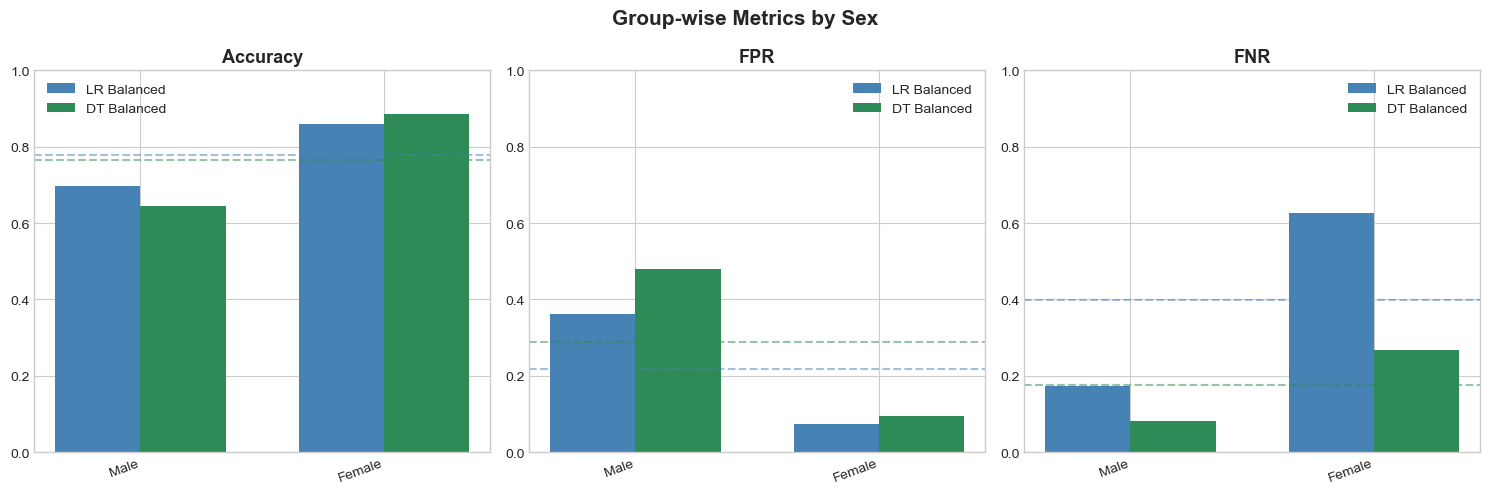

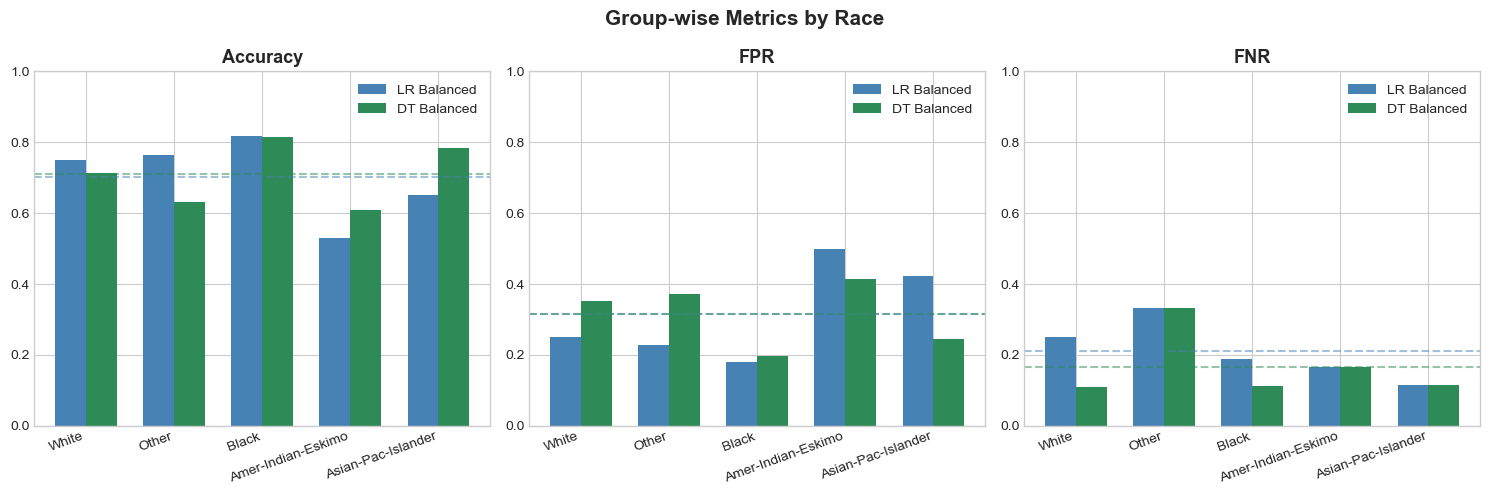

In [60]:
def plot_group_metrics(df_lr, df_dt, title):
    metrics = ['Accuracy', 'FPR', 'FNR']
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for ax, metric in zip(axes, metrics):
        x = np.arange(len(df_lr))
        width = 0.35
        ax.bar(x - width/2, df_lr[metric], width, label='LR Balanced', color='steelblue')
        ax.bar(x + width/2, df_dt[metric], width, label='DT Balanced', color='seagreen')
        ax.set_title(metric, fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(df_lr.index, rotation=20, ha='right')
        ax.set_ylim(0, 1)
        ax.legend()
        ax.axhline(y=df_lr[metric].mean(), color='steelblue', linestyle='--', alpha=0.5)
        ax.axhline(y=df_dt[metric].mean(), color='seagreen', linestyle='--', alpha=0.5)
        # dashed lines = overall average — bars above/below show which groups deviate

    plt.suptitle(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_group_metrics(df_sex_lr, df_sex_dt, 'Group-wise Metrics by Sex')
plot_group_metrics(df_race_lr, df_race_dt, 'Group-wise Metrics by Race')

Each chart shows three metrics (Accuracy, FPR, FNR) across demographic groups. The dashed lines represent the overall average for each model — bars above the dashed line indicate groups that perform worse than average, bars below indicate groups that perform better.

Key patterns:
- In the Sex chart, the FNR panel shows the starkest disparity — the female bar is 3–4x higher than the male bar in both models
- In the Race chart, disparities are more evenly distributed, with no single racial group dominating all three metrics
- DT balanced (green) consistently shows lower FNR bars than LR balanced (blue), confirming it as the fairer model

### Section 2.4 - Intersectional Analysis (Gender x race)
Single-attribute analysis can hide compound disadvantage. A model may seem fair to women overall and fair to Black individuals overall, but "Black Female" as a combined group may have significantly higher FNR. This is what single-attribute analysis misses entirely.

In [57]:
df_eval['sex_race'] = df_eval['sex'] + ' + ' + df_eval['race']

results_intersect_lr, results_intersect_dt = [], []

for group in df_eval['sex_race'].unique():
    mask = df_eval['sex_race'] == group
    # Only compute for groups with enough samples — small groups give unreliable metrics
    if mask.sum() < 30:
        continue
    metrics_lr = group_metrics(df_eval[mask]['true'], df_eval[mask]['pred_lr'])
    metrics_dt = group_metrics(df_eval[mask]['true'], df_eval[mask]['pred_dt'])
    metrics_lr['Group'] = group
    metrics_dt['Group'] = group
    results_intersect_lr.append(metrics_lr)
    results_intersect_dt.append(metrics_dt)

df_intersect_lr = pd.DataFrame(results_intersect_lr).set_index('Group')
df_intersect_dt = pd.DataFrame(results_intersect_dt).set_index('Group')

print("Logistic Regression — Intersectional Analysis (sex × race):")
print(df_intersect_lr.sort_values('FNR', ascending=False))
print("\nDecision Tree — Intersectional Analysis (sex × race):")
print(df_intersect_dt.sort_values('FNR', ascending=False))

Logistic Regression — Intersectional Analysis (sex × race):
                             Accuracy    FPR    FNR
Group                                              
Female + White                  0.853  0.072  0.647
Female + Black                  0.914  0.057  0.500
Female + Asian-Pac-Islander     0.810  0.158  0.500
Male + White                    0.703  0.353  0.181
Male + Black                    0.725  0.326  0.097
Male + Asian-Pac-Islander       0.569  0.600  0.053
Male + Amer-Indian-Eskimo       0.415  0.632  0.000

Decision Tree — Intersectional Analysis (sex × race):
                             Accuracy    FPR    FNR
Group                                              
Female + Asian-Pac-Islander     0.857  0.123  0.333
Female + White                  0.880  0.098  0.271
Female + Black                  0.918  0.073  0.222
Male + Black                    0.714  0.344  0.081
Male + White                    0.639  0.495  0.080
Male + Asian-Pac-Islander       0.748  0.329  0.079
M

### Observations - Intersectional Analysis (sex × race)

**FNR is a female problem across all racial groups, not a race problem.**
Every female group sits at the top of the FNR ranking regardless of race. Female + White has the highest FNR in LR balanced (0.647), followed by Female + Black and Female + Asian-Pac-Islander (both 0.500). Every male group has FNR below 0.200 in both models.

**LR balanced is significantly worse for women than DT balanced:**
- Female + White: 0.647 → 0.271
- Female + Black: 0.500 → 0.222  
- Female + Asian-Pac-Islander: 0.500 → 0.333

**Male + Amer-Indian-Eskimo has FNR = 0.000 in both models.** This requires a caveat — this group has very few >$50K individuals in the test set, so 0.000 FNR likely reflects insufficient data rather than genuine fairness. This is itself a bias finding: the dataset does not represent this group adequately enough to make reliable fairness claims.

**The intersectional insight:** The by-sex chart showed high female FNR overall. The by-race chart showed relatively even FNR. One could have concluded race does not matter. But Female + Black and Female + Asian-Pac-Islander both show 0.500 FNR in LR balanced — they are being harmed by both gender and race simultaneously. Single-attribute analysis would have hidden this compound disadvantage entirely.

### Section 2.5 - Intersectional Heatmap
A heatmap is the clearest way to show intersectional FNR. 
>Darker cells = higher FNR = model fails this group most. 


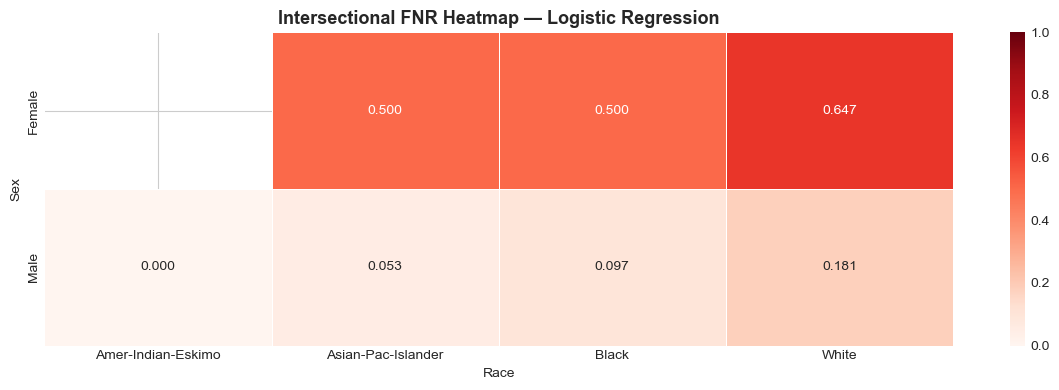

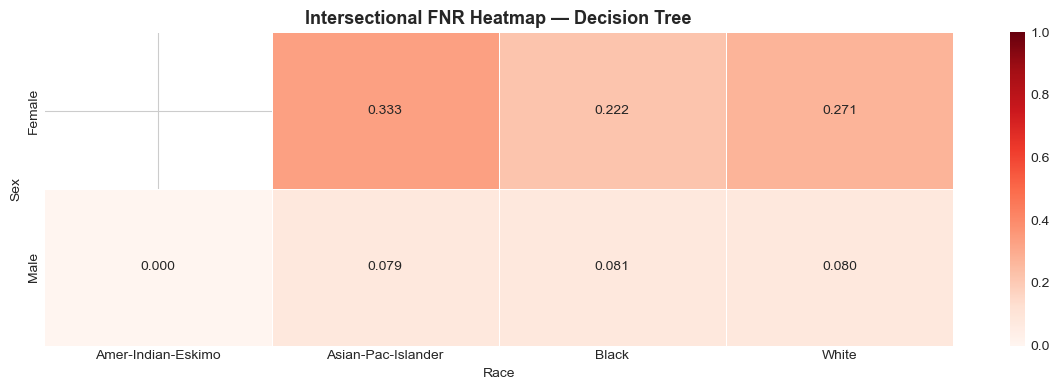

In [61]:
def intersectional_heatmap(df_intersect, model_name):
    # Split group label back into sex and race for pivot
    df_plot = df_intersect.reset_index()
    df_plot[['Sex', 'Race']] = df_plot['Group'].str.split(' \+ ', expand=True)
    pivot = df_plot.pivot(index='Sex', columns='Race', values='FNR')
    
    plt.figure(figsize=(12, 4))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Reds',
                linewidths=0.5, vmin=0, vmax=1)
    plt.title(f'Intersectional FNR Heatmap — {model_name}', 
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'intersectional_heatmap_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

intersectional_heatmap(df_intersect_lr, 'Logistic Regression')
intersectional_heatmap(df_intersect_dt, 'Decision Tree')

The two-row pattern is unambiguous: the entire female row is consistently darker than the entire male row across both models. This is not a result of cherry-picking — every female group, regardless of race, shows elevated FNR.

**Missing cell (Female + Amer-Indian-Eskimo):** This group had fewer than 30 samples in the test set and was excluded from computation. Fairness metrics on very small groups are statistically unreliable. The absence of this cell is itself a data representation problem — the dataset does not contain enough Female + Amer-Indian-Eskimo individuals to audit the model's behaviour toward them.

**Before/after comparison:** The LR heatmap (0.500–0.647 female row) vs DT heatmap (0.222–0.333 female row) tells a clear story: DT balanced substantially reduces the FNR disparity while maintaining the same structural pattern. The bias is reduced but not eliminated — gender remains the primary axis of unfairness even after balancing.

## Section 3 - Analysis Summary & Questions for Week 8

### What we found this week

1. **Balancing changes the error composition, not just the numbers:** Both models improve minority class recall significantly after applying `class_weight='balanced'`. The total error count increases, but the harmful errors (FN) drop sharply. For income prediction this is the right tradeoff.

2. **Depth 3 is enough when the model is balanced:** The optimal DT depth dropped from 13 to 3 after balancing. The class weights do the work that extra depth was previously doing — and the simpler tree is more interpretable.

3. **Gender is the dominant axis of unfairness:** Female FNR is 3–4x higher than male FNR in both models across all racial groups. The model systematically under-classifies high-income women regardless of race.

4. **Intersectional analysis reveals what single-attribute analysis hides:** Female + Black and Female + Asian-Pac-Islander both show compounded disadvantage. Looking at sex or race alone would have missed this.

5. **DT balanced is the fairer model:** It reduces female FNR from 0.647 to 0.271 while keeping male FNR stable. It is the recommended model for all downstream fairness analysis.

6. **Some groups cannot be audited:** Female + Amer-Indian-Eskimo had fewer than 30 test samples and was excluded. The dataset does not represent this group adequately — which is itself a bias finding.

### Limitations of this analysis

1. **Binary sensitive attributes only:** Sex is treated as Male/Female and race uses 1994 US Census categories. Non-binary individuals do not exist in this data. "Amer-Indian-Eskimo" combines distinct groups into one. Our fairness claims inherit these categorisation choices.

2. **FNR as the only harm metric:** We prioritised FNR as the harmful error. This reflects a domain judgment — denying a high-income classification is worse than wrongly granting one. A different use case would require different priorities.

3. **Small group instability:** Groups with fewer than 30 test samples were excluded. This is a necessary but arbitrary cutoff. Smaller groups get less protection from this analysis, not more — the groups hardest to represent are the ones we cannot audit.

4. **Test set dependence:** All metrics are computed on a single 80/20 split. Group-level metrics on small subgroups (e.g. Female + Asian-Pac-Islander, n≈60) have high variance — a different random seed could shift the numbers meaningfully.

5. **No causal claims:** Finding that Female FNR = 0.647 does not mean the model is using sex to make decisions. It means the outcomes are disparate. Whether that disparity is caused by sex, by proxy features correlated with sex, or by data underrepresentation is a question SHAP analysis will begin to answer in Week 8.

6. **Static dataset:** The Adult Census data is from 1994. Income patterns, demographic distributions, and labour market structures have changed substantially. Fairness findings on this dataset may not generalise to current real-world income prediction.

### Open questions going into Week 8

- Why does the model under-classify women? Which features are driving this — and are they proxies for gender?
- Does the model use different features to make decisions for male vs female groups, or the same features with different weights?
- How do SHAP values differ across demographic groups — and does balancing change which features matter most?

## Section 4 - Save Models & Outputs

In [64]:
# Save balanced trained models
joblib.dump(lr_bal, 'lr_balanced_model.pkl')
joblib.dump(dt_bal, 'dt_balanced_model.pkl')

# Save balanced predictions
pd.Series(y_pred_lr_bal, name='y_pred_lr_bal').to_csv('predictions_lr_bal.csv', index=False)
pd.Series(y_pred_dt_bal, name='y_pred_dt_bal').to_csv('predictions_dt_bal.csv', index=False)

df_eval.to_csv('df_eval.csv', index=False)

print('Saved:')
print('  lr_balanced_model.pkl       — balanced LR model')
print('  dt_balanced_model.pkl       — balanced DT (depth=3)')
print('  predictions_lr_bal.csv      — balanced LR predictions')
print('  predictions_dt_bal.csv      — balanced DT predictions')
print('  df_eval.csv                 — DataFrame containing true labels, predictions and senstive columns')


Saved:
  lr_balanced_model.pkl       — balanced LR model
  dt_balanced_model.pkl       — balanced DT (depth=3)
  predictions_lr_bal.csv      — balanced LR predictions
  predictions_dt_bal.csv      — balanced DT predictions
  df_eval.csv                 — DataFrame containing true labels, predictions and senstive columns
